In [7]:
# FIFA World Cup Match Outcome Prediction

Objective

The goal of this project is to analyze historical FIFA World Cup matches and build a machine learning model capable of predicting match outcomes.

The project includes:

Data Cleaning

Exploratory Data Analysis (EDA)

Feature Engineering

Machine Learning

Model Evaluation

SyntaxError: invalid syntax (3511394526.py, line 5)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Load Dataset

In [10]:
df = pd.read_csv("../data/WorldCupMatches.csv")

print(df.shape)
df.head()

(4572, 20)


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [11]:
# data cleaning

In [12]:
df=df.dropna(subset=["Home Team Name"])

print("Rows after cleaning", len(df))

Rows after cleaning 852


In [13]:
#total missing values
df.isnull().sum()

Year                    0
Datetime                0
Stage                   0
Stadium                 0
City                    0
Home Team Name          0
Home Team Goals         0
Away Team Goals         0
Away Team Name          0
Win conditions          0
Attendance              2
Half-time Home Goals    0
Half-time Away Goals    0
Referee                 0
Assistant 1             0
Assistant 2             0
RoundID                 0
MatchID                 0
Home Team Initials      0
Away Team Initials      0
dtype: int64

In [14]:
#checking for duplicate rows
df.duplicated().sum()

np.int64(16)

In [15]:
df=df.drop_duplicates()

In [16]:
print("Rows after removing duplicates: ", len(df))

Rows after removing duplicates:  836


In [17]:
df.dtypes

Year                    float64
Datetime                 object
Stage                    object
Stadium                  object
City                     object
Home Team Name           object
Home Team Goals         float64
Away Team Goals         float64
Away Team Name           object
Win conditions           object
Attendance              float64
Half-time Home Goals    float64
Half-time Away Goals    float64
Referee                  object
Assistant 1              object
Assistant 2              object
RoundID                 float64
MatchID                 float64
Home Team Initials       object
Away Team Initials       object
dtype: object

In [18]:
df["Year"].head()

0    1930.0
1    1930.0
2    1930.0
3    1930.0
4    1930.0
Name: Year, dtype: float64

In [19]:
df["Year"]=df["Year"].astype(int)
df["Year"].head()

0    1930
1    1930
2    1930
3    1930
4    1930
Name: Year, dtype: int64

In [20]:
# creating results column
def get_result(row):
    if(row["Home Team Goals"] > row["Away Team Goals"]):
        return "Home Win"
    elif(row["Home Team Goals"] < row["Away Team Goals"]):
        return "Away Win"
    else:
        return "Draw"
df["Results"]=df.apply(get_result, axis=1)
df["Results"].value_counts()

Results
Home Win    479
Draw        186
Away Win    171
Name: count, dtype: int64

In [21]:
df["Total Goals"]=(df["Home Team Goals"] + df["Away Team Goals"])

df[["Total Goals", "Home Team Goals", "Away Team Goals"]].head()

,Total Goals,Home Team Goals,Away Team Goals
0,5.0,4.0,1.0
1,3.0,3.0,0.0
2,3.0,2.0,1.0
3,4.0,3.0,1.0
4,1.0,1.0,0.0


In [22]:
# FInal dataset check

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 836
Columns: 22


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,...,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials,Results,Total Goals
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,...,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX,Home Win,5.0
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,...,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL,Home Win,3.0
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,...,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA,Home Win,3.0
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,...,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER,Home Win,4.0
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,...,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA,Home Win,1.0


In [23]:
# EDA (Exploratory Data Analysis)

In [24]:
df["Results"].value_counts()

Results
Home Win    479
Draw        186
Away Win    171
Name: count, dtype: int64

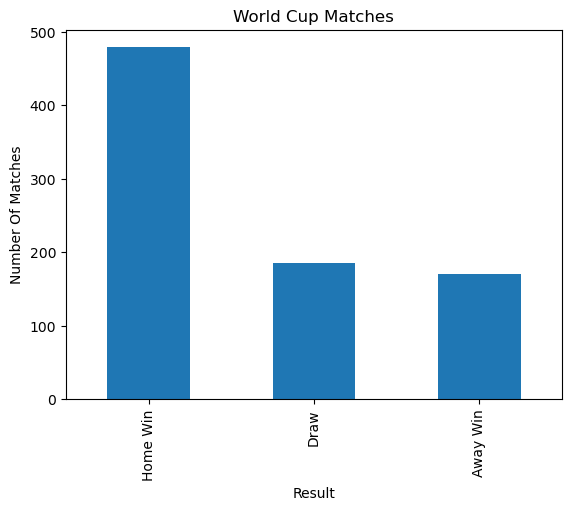

In [25]:
df["Results"].value_counts().plot(kind="bar")

plt.title("World Cup Matches")
plt.xlabel("Result")
plt.ylabel("Number Of Matches")
plt.show()

In [26]:
home_wins=df[df["Results"]=="Home Win"]["Home Team Name"]
away_wins=df[df["Results"]=="Away Win"]["Away Team Name"]
winners=pd.concat([home_wins, away_wins])
top_winners=winners.value_counts().head(10)
top_winners

Brazil         70
Italy          45
Argentina      42
Germany FR     36
Germany        30
Spain          29
France         28
Netherlands    27
England        26
Uruguay        20
Name: count, dtype: int64

[]

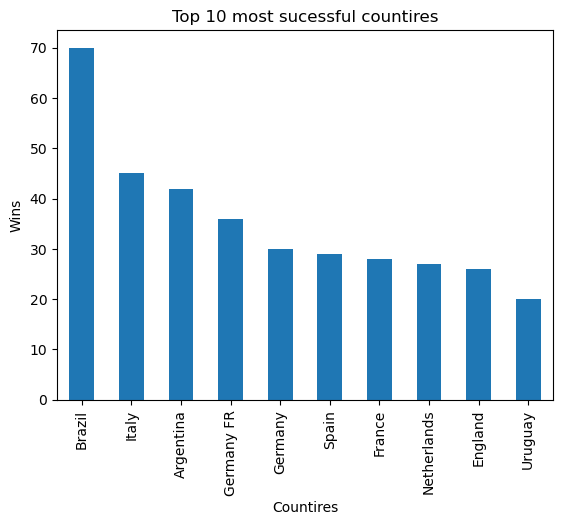

In [27]:
top_winners.plot(kind="bar")

plt.title("Top 10 most sucessful countires")
plt.xlabel("Countires")
plt.ylabel("Wins")
plt.plot()

In [28]:
matches_played=pd.concat([df["Home Team Name"], df["Away Team Name"]])
top_matches=matches_played.value_counts().head(10)
top_matches

Brazil         104
Italy           83
Argentina       77
Germany FR      62
England         62
Spain           59
France          59
Mexico          53
Uruguay         51
Netherlands     50
Name: count, dtype: int64

[]

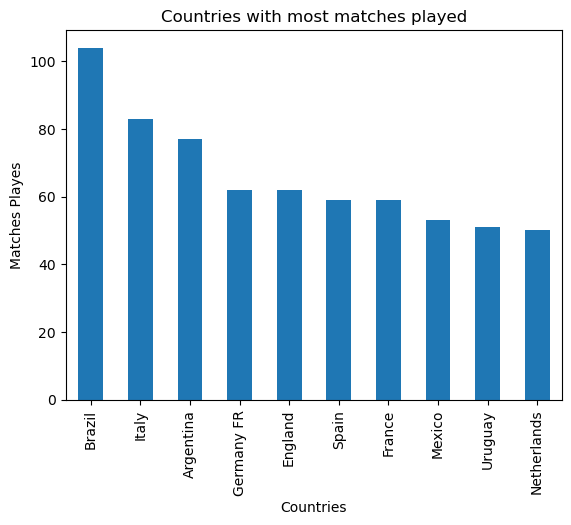

In [29]:
top_matches.plot(kind="bar")
plt.title("Countries with most matches played")
plt.xlabel("Countries")
plt.ylabel("Matches Playes")
plt.plot()

In [30]:
print(
    "Average Goals Per Match:",
    round(df["Total Goals"].mean(), 2)
)

Average Goals Per Match: 2.85


In [34]:
# Feature Engineering

#Feature engineering is the process of transforming raw data into numerical features that a machine learning model can understand.

In [37]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
team_encoder=LabelEncoder()

In [36]:
all_teams=pd.concat([df["Away Team Name"], df["Home Team Name"]]).unique()
all_teams

array(['Mexico', 'Belgium', 'Brazil', 'Peru', 'France', 'Bolivia',
       'Paraguay', 'Romania', 'Chile', 'USA', 'Yugoslavia', 'Argentina',
       'Egypt', 'Netherlands', 'Switzerland', 'Sweden', 'Spain',
       'Hungary', 'Austria', 'Germany', 'Czechoslovakia',
       'Dutch East Indies', 'Norway', 'Poland', 'Cuba', 'Italy',
       'England', 'Scotland', 'Turkey', 'Korea Republic', 'Germany FR',
       'Uruguay', 'Wales', 'Northern Ireland', 'Soviet Union', 'Colombia',
       'Bulgaria', 'Korea DPR', 'Portugal', 'Israel', 'Morocco',
       'El Salvador', 'Australia', 'Haiti', 'German DR', 'Zaire',
       'IR Iran', 'Tunisia', 'Iran', 'Cameroon', 'New Zealand', 'Algeria',
       'Honduras', 'Kuwait', 'Iraq', 'Denmark', 'Canada',
       'rn">Republic of Ireland', 'rn">United Arab Emirates',
       'Costa Rica', 'Saudi Arabia', 'Russia', 'Greece', 'Nigeria',
       'South Africa', 'Japan', 'Croatia', 'Jamaica', 'Senegal',
       'Slovenia', 'Ecuador', 'China PR', "C�te d'Ivoire",
       

In [38]:
team_encoder.fit(all_teams)

LabelEncoder()

In [44]:
df["HomeEncoded"]=team_encoder.transform(df["Home Team Name"])
df[["Home Team Name", "HomeEncoded"]].head()

,Home Team Name,HomeEncoded
0,France,26
1,USA,72
2,Yugoslavia,76
3,Romania,56
4,Argentina,2


In [54]:
df["AwayEncoded"]=team_encoder.transform(df["Away Team Name"])
df[["Away Team Name", "AwayEncoded"]].head()

,Away Team Name,AwayEncoded
0,Mexico,45
1,Belgium,5
2,Brazil,7
3,Peru,53
4,France,26


In [50]:
result_encoder=LabelEncoder()
df["ResultEncoded"]=result_encoder.fit_transform(df["Results"])
df[["Results", "ResultEncoded"]].head()

,Results,ResultEncoded
0,Home Win,2
1,Home Win,2
2,Home Win,2
3,Home Win,2
4,Home Win,2


In [53]:
print(result_encoder.classes_)

['Away Win' 'Draw' 'Home Win']


In [59]:
X=df[["HomeEncoded", "AwayEncoded"]]
X.head()

,HomeEncoded,AwayEncoded
0,26,45
1,72,5
2,76,7
3,56,53
4,2,26


In [60]:
y=df["ResultEncoded"]
y.head()

0    2
1    2
2    2
3    2
4    2
Name: ResultEncoded, dtype: int64

In [61]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (836, 2)
Target vector shape: (836,)


In [62]:
# Model Training

#In this section, we split the dataset into training and testing sets, train a Random Forest classifier, and evaluate its performance.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
print("Training example:", X_train.shape[0])
print("Testing example: ", X_test.shape[0])

Training example: 668
Testing example:  168


In [65]:
# creating the model

In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [67]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
# Model Evaluation

In [69]:
predictions=model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, predictions)
print(f"Accuracy {accuracy:.2%}")

Accuracy 51.19%


In [72]:
#confusion matrix

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[ 9  7 19]
 [ 4  5 32]
 [11  9 72]]


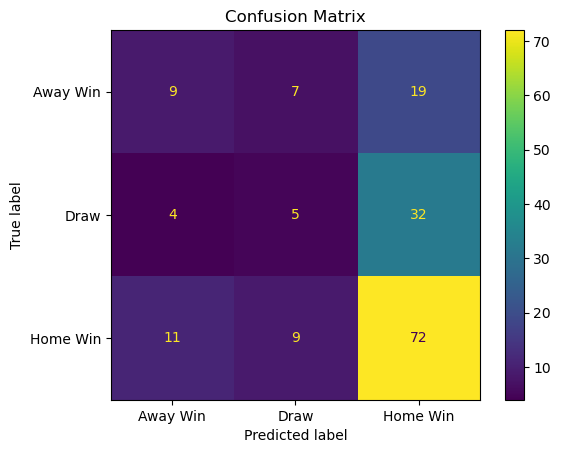

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=result_encoder.classes_).plot()

plt.title("Confusion Matrix")
plt.show()

In [75]:
# predicting a match

In [76]:
def predict_match(home_team, away_team):
    home = team_encoder.transform([home_team])[0]
    away = team_encoder.transform([away_team])[0]

    prediction = model.predict([[home, away]])
    probabilities = model.predict_proba([[home, away]])[0]

    predicted_result = result_encoder.inverse_transform(prediction)[0]

    print(f"{home_team} vs {away_team}")
    print(f"Predicted Result: {predicted_result}")
    print("\nProbabilities:")

    for label, probability in zip(result_encoder.classes_, probabilities):
        print(f"{label}: {probability:.2%}")

In [77]:
predict_match("Brazil", "Germany")

Brazil vs Germany
Predicted Result: Away Win

Probabilities:
Away Win: 71.89%
Draw: 2.69%
Home Win: 25.42%


C:\Users\amite\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\amite\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [82]:
predict_match("Brazil", "Argentina")

Brazil vs Argentina
Predicted Result: Away Win

Probabilities:
Away Win: 61.00%
Draw: 1.50%
Home Win: 37.50%


C:\Users\amite\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\amite\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
